In [1]:
# Step 1 - We will load reviews 
import pandas as pd

df = pd.read_csv("/home/ishanya-poddar/Desktop/Projects/ML + NLP/ML&NLP/Datasets/Processed Datasets/cleaned_data.csv")

reviews_df = df[["review_score", "review_comment_message"]].dropna()

In [2]:
# Step 2 - We will perform Text Cleaning 
import re 
import nltk 
from nltk.corpus import stopwords 

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

reviews_df["clean_text"] = reviews_df["review_comment_message"].apply(clean_text)

[nltk_data] Downloading package stopwords to /home/ishanya-
[nltk_data]     poddar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Step 3 - Create a Sentiment Label 
def convert_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

reviews_df["sentiment"] = reviews_df["review_score"].apply(convert_sentiment)      

In [4]:
# Step 4 - Perform 'Term Frequency [TF] - Inverse Document Frequency [IDF]' 
from sklearn.feature_extraction.text import TfidfVectorizer 

tfidf = TfidfVectorizer(max_features = 5000)
X = tfidf.fit_transform(reviews_df["clean_text"])
y = reviews_df["sentiment"]

In [5]:
# Step 5 - Train Model 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

    Negative       0.78      0.89      0.83      2768
     Neutral       0.54      0.11      0.18       854
    Positive       0.90      0.94      0.92      5907

    accuracy                           0.85      9529
   macro avg       0.74      0.65      0.64      9529
weighted avg       0.83      0.85      0.83      9529



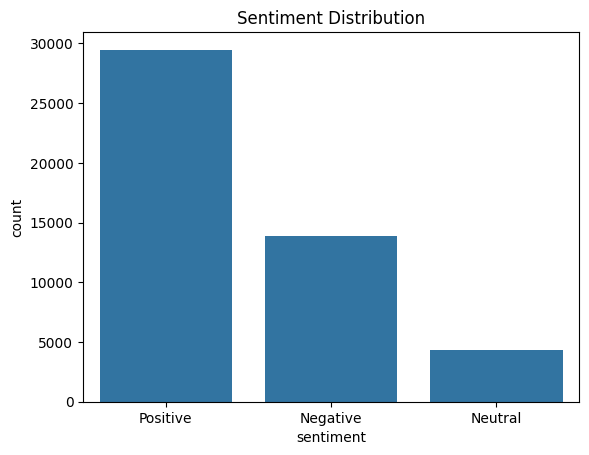

In [6]:
# Step 6 - Sentiment Distribution 
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x = "sentiment", data = reviews_df)
plt.title("Sentiment Distribution")
plt.show()

In [7]:
# Step 7 - Extract the Top Keywords 
feature_names = tfidf.get_feature_names_out()
top_words = feature_names[:20]
print(top_words)

['001689' '01' '01082018' '01um' '02' '02082017' '03' '04' '0404'
 '04abril' '05' '0501' '0502' '05un' '06' '0610' '07' '0702' '08' '09']
